# What do the ensemble's higher moments know about its own signal?

At each grid cell and each timestep the 49 ensemble members form a distribution. This
notebook asks how much information the **shape** of that distribution carries about the
ensemble's own signal $s$ (the ensemble mean), moment by moment: the spread, and the
standardised central moments of order 3 through 6.

$$I(\sigma_F; s),\quad I(m_3; s),\quad I(m_4; s),\quad I(m_5; s),\quad I(m_6; s)$$

where $m_k = \overline{(f-\bar f)^k}/\sigma_F^{\,k}$, so $m_3$ is skewness and $m_4$ is
kurtosis. No observations are involved anywhere -- this is entirely model-internal. The
question is whether the ensemble's uncertainty is *state-dependent*: does the shape of the
forecast distribution depend on what the forecast actually is?

The null expectation is sharp. Under one forced signal plus **homoscedastic** independent
Gaussian noise, the sample mean is independent of every sample central moment, so all five
quantities are zero. Anything above zero is state dependence.

Each is reported three ways -- as $\lambda$ from the raw MI, as $\lambda$ from the
null-corrected MI, and as a Pearson correlation -- and each is computed both on the data as
it comes and after removing the annual cycle.

Split out of `calc_RPC_infomeasure.ipynb`, which was getting crowded. Estimation goes
through the same `scripts/infomeasure_rpc.py` adapter, so the conventions (bits,
`noise_level=0`, max norm, rank/copula transform, $k=5$) match that notebook exactly.

In [1]:
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import cartopy.crs as ccrs

sys.path.insert(0, "../scripts")
import infomeasure_rpc as R
import infomeasure as im

rc('font', **{'family': 'sans-serif', 'serif': ['Helvetica']})
rc('text', usetex=False)
print("infomeasure", im.__version__)

infomeasure 0.6.2


## Data

`R.load_data` is `calc_RPC.ipynb` cell 3 verbatim -- the canonical preprocessing, verified
bit-identical. Ensemble is `(49, 120, 64, 128)`: 49 members, 120 monthly steps
(1962-01 to 1971-12), on a 64x128 grid.

In [2]:
DATA = "../data" if os.path.isdir("../data/ensembles") else \
    "/Users/jasperchen/Academics/Research/SNP/information-snp/data"
f, s, obs = R.load_data(data_dir=DATA)
lats, lons = f["lat"].to_numpy(), f["lon"].to_numpy()
print("ensemble", f.psl.shape, "  N=%d members, T=%d months" % f.psl.shape[:2])

# Map helper. The grid runs 0..357 degrees east; drawn with that extent in a global
# PlateCarree frame cartopy leaves a white seam at the prime meridian, so roll to
# -180..180 first. tight_layout() is avoided -- it breaks cartopy 0.25 / shapely 2.1.
PROJ = ccrs.PlateCarree()
LON180 = ((lons + 180) % 360) - 180
ORDER = np.argsort(LON180)
EXTENT = [LON180[ORDER].min(), LON180[ORDER].max(), lats.min(), lats.max()]


def panel(ax, field, cmap, norm, title):
    ax.set_global()
    h = ax.imshow(field[:, ORDER], origin="lower", extent=EXTENT, transform=PROJ,
                  cmap=cmap, norm=norm)
    # mid-grey coastlines: most of these panels are near-black under `magma`, where
    # default black outlines vanish, but a light line would vanish on the bright ones
    ax.coastlines(linewidth=0.4, color="0.6")
    ax.set_title(title, fontsize=9)
    return h

ensemble (49, 120, 64, 128)   N=49 members, T=120 months


## The five moments, and two things that would otherwise fool us

**NaN handling.** Members 10..19 are NaN for all of calendar 1971, and the published policy
fills NaNs with `0.0`. Ten hard zeros among 49 values is a severe outlier cluster, and the
higher the moment the more violently it responds -- a sixth power turns an outlier into a
dominant term. So the moments are computed **nan-aware** (`np.nanmean` of the central
powers) and only the resulting time series is zero-filled. Verified against `scipy.stats`
on complete timesteps below.

Moments are used raw, as $m_k = \overline{(f-\bar f)^k}/\sigma_F^{\,k}$, without subtracting
the Gaussian reference value (3 for $k=4$, 15 for $k=6$). Subtracting a constant is
irrelevant to everything computed here: the MI estimator is rank-based so a shift leaves it
bit-identical, and Pearson correlation is shift-invariant by construction.

**The annual cycle.** Preprocessing removes a linear trend and *never* a seasonal cycle,
and these are monthly fields. 93% of $s$'s variance sits in the month-of-year climatology.
Any raw $I(\cdot\,;s)$ therefore largely reports *"both series know which month it is."*
Everything below is computed twice: as-is, and after subtracting the month-of-year
climatology from both sides.

**And the thing that limits the whole exercise.** A moment of order $k$ estimated from 49
members is itself noisy, and the noise grows fast with $k$. The cell measures it directly
by Monte Carlo rather than relying on asymptotic formulae, which are inaccurate at $N=49$.

In [3]:
def moments(A):
    # nan-aware spread and standardised central moments of order 3..6, over axis 0
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)      # all-NaN timesteps
        d = A - np.nanmean(A, axis=0)
        d2 = d * d
        m2 = np.nanmean(d2, axis=0)
        out = [np.sqrt(m2)]
        for k, powr in ((3, d2 * d), (4, d2 * d2), (5, d2 * d2 * d), (6, d2 * d2 * d2)):
            out.append(np.nanmean(powr, axis=0) / m2 ** (k / 2.0))
        del d, d2
    return tuple(np.nan_to_num(a, nan=0.0) for a in out)


SD, M3, M4, M5, M6 = moments(f.psl.to_numpy())
SGN = np.nan_to_num(s.psl.to_numpy(), nan=0.0)          # published skipna ensemble mean
month = np.arange(SGN.shape[0]) % 12

# verify against scipy on the complete timesteps of one column
from scipy.stats import skew as _sk, kurtosis as _ku
_sub = f.psl.to_numpy()[:, :, 32, 21]
_ok = ~np.isnan(_sub).any(axis=0)
_m = moments(_sub)
print("vs scipy on %d complete timesteps:  std %.1e   skew %.1e   kurt %.1e"
      % (_ok.sum(),
         np.max(np.abs(_m[0][_ok] - np.std(_sub[:, _ok], axis=0))),
         np.max(np.abs(_m[1][_ok] - _sk(_sub[:, _ok], axis=0))),
         np.max(np.abs((_m[2][_ok] - 3) - _ku(_sub[:, _ok], axis=0)))))


def deseason(a):
    out = a.copy()
    for m in range(12):
        sel = month == m
        out[sel] = a[sel] - a[sel].mean(axis=0, keepdims=True)
    return out


def seas_frac(a):
    clim = np.zeros_like(a)
    for m in range(12):
        sel = month == m
        clim[sel] = a[sel].mean(axis=0, keepdims=True)
    v = a.var(axis=0)
    return float(np.nanmean(np.where(v > 0, clim.var(axis=0) / np.where(v > 0, v, 1), np.nan)))


print("\nfraction of variance in the month-of-year climatology")
for nm, a in (("s (mean)", SGN), ("spread", SD), ("m3 skew", M3),
              ("m4 kurt", M4), ("m5", M5), ("m6", M6)):
    print("  %-10s %.3f" % (nm, seas_frac(a)))

# Sampling noise of each standardised moment, measured rather than assumed: draw many
# Gaussian samples of size N and look at the spread of the resulting moment. Asymptotic
# formulae (6/N, 24/N) are noticeably off at N=49.
N = f.psl.shape[0]
_g = np.random.default_rng(0).normal(size=(200000, N))
_d = _g - _g.mean(axis=1, keepdims=True)
_m2 = (_d ** 2).mean(axis=1)
print("\nMonte-Carlo sampling noise of each moment, Gaussian members, N=%d" % N)
print("  %-4s %10s %10s %12s" % ("k", "noise sd", "observed", "noise/observed"))
NOISE = {}
for k, arr in ((3, M3), (4, M4), (5, M5), (6, M6)):
    sd = ((_d ** k).mean(axis=1) / _m2 ** (k / 2.0)).std()
    NOISE[k] = sd
    print("  %-4d %10.3f %10.3f %11.0f%%" % (k, sd, arr.std(), 100 * sd / arr.std()))
print("  noise grows %.0fx from k=3 to k=6" % (NOISE[6] / NOISE[3]))
del _g, _d, _m2

vs scipy on 108 complete timesteps:  std 2.8e-14   skew 1.3e-15   kurt 5.3e-15

fraction of variance in the month-of-year climatology
  s (mean)   0.934
  spread     0.665
  m3 skew    0.227
  m4 kurt    0.128
  m5         0.185
  m6         0.119

Monte-Carlo sampling noise of each moment, Gaussian members, N=49
  k      noise sd   observed noise/observed
  3         0.330      0.427          77%


  4         0.603      0.783          77%
  5         3.159      4.447          71%
  6         8.158     12.790          64%
  noise grows 25x from k=3 to k=6


## The grids

Ten fields: five moments $\times$ (as-is, deseasonalised). Each grid cell gets its own
10-permutation null, and only the **excess** $I - \mathrm{null}$ is interpreted -- a bare MI
at $T=120$ is not meaningful, and the null differs from field to field.

The cache is filled incrementally: whatever is already stored is reused, and only missing
combinations are computed. A cold run of all ten is about 8 minutes.

In [4]:
CACHE = "../data/ensemble_moments_cache.npz"
MOMENTS = [("spread", SD), ("skewness", M3), ("kurtosis", M4),
           ("moment5", M5), ("moment6", M6)]
VERSIONS = ["as-is", "deseasonalised"]
N_PERM = 10

EX = {}
if os.path.exists(CACHE):
    _z = np.load(CACHE)
    EX = {k: _z[k] for k in _z.files}
    print("cache holds %d arrays" % len(EX))

SGN_ds = deseason(SGN)
todo = [(nm, tag) for nm, _ in MOMENTS for tag in VERSIONS
        if "%s|%s" % (nm, tag) not in EX]
print("to compute: %s" % (todo if todo else "nothing, all cached"))

for nm, M in MOMENTS:
    for tag in VERSIONS:
        if (nm, tag) not in todo:
            continue
        A = M if tag == "as-is" else deseason(M)
        B = SGN if tag == "as-is" else SGN_ds
        I = np.empty(SGN.shape[1:])
        NL = np.empty(SGN.shape[1:])
        for la in range(SGN.shape[1]):
            for lo in range(SGN.shape[2]):
                x, y = A[:, la, lo], B[:, la, lo]
                I[la, lo] = R.mi_bits(x, y, "ksg", param=5)
                rng = np.random.default_rng(la * 1000 + lo)
                NL[la, lo] = np.mean([R.mi_bits(x, rng.permutation(y), "ksg", param=5)
                                      for _ in range(N_PERM)])
        key = "%s|%s" % (nm, tag)
        EX[key], EX[key + "|I"], EX[key + "|null"] = I - NL, I, NL
        print("  done %-9s %s" % (nm, tag))
if todo:
    np.savez_compressed(CACHE, **EX)
    print("cached ->", CACHE)

print("\n%-10s %-15s %8s %8s %9s %11s"
      % ("moment", "version", "I", "null", "excess", "excess>0 (area)"))
for nm, _ in MOMENTS:
    for tag in VERSIONS:
        k = "%s|%s" % (nm, tag)
        print("%-10s %-15s %8.4f %8.4f %+9.4f %10.1f%%"
              % (nm, tag, np.nanmean(EX[k + "|I"]), np.nanmean(EX[k + "|null"]),
                 np.nanmean(EX[k]),
                 100 * R.area_weighted_fraction(EX[k], lats, threshold=0.0)))
print("\n(50% area would be expected by chance)")

cache holds 30 arrays


to compute: nothing, all cached

moment     version                I     null    excess excess>0 (area)
spread     as-is             0.4776   0.0313   +0.4463       97.5%
spread     deseasonalised    0.0526   0.0322   +0.0205       59.0%
skewness   as-is             0.1064   0.0315   +0.0749       74.3%
skewness   deseasonalised    0.0375   0.0316   +0.0059       53.2%
kurtosis   as-is             0.0495   0.0319   +0.0176       58.6%
kurtosis   deseasonalised    0.0319   0.0316   +0.0003       49.0%
moment5    as-is             0.0981   0.0316   +0.0665       73.1%
moment5    deseasonalised    0.0350   0.0316   +0.0034       51.8%
moment6    as-is             0.0476   0.0317   +0.0159       57.9%
moment6    deseasonalised    0.0310   0.0316   -0.0006       48.4%

(50% area would be expected by chance)


## Maps, as $\lambda$

$\lambda = \sqrt{1 - 2^{-2I}}$, with the argument of the square root clamped at zero.
For $I<0$ that argument is negative, so those cells become $\lambda = 0$; this is
algebraically identical to clamping $I$ at zero first, and the cell checks the two agree
exactly. $\lambda$ is dimensionless, bounded by 1, and under a Gaussian model it *is* the
equivalent correlation -- so it can be compared directly against the Pearson $r$ maps
below.

Two figures on a shared 0-1 scale, one row per moment, as-is left and deseasonalised right:
**$\lambda$ from raw $I$** and **$\lambda$ from excess**.

Unlike the same pair plotted in bits, these two genuinely differ, and the reason is worth
keeping in mind. $\lambda$ is steep near $I=0$: the null floor of 0.032 bits maps to
$\lambda = 0.208$, which is 21% of this colour scale where it was only 5% of the bits
scale. **The square root magnifies exactly the region where the estimator is least
reliable.** So a raw-$I$ $\lambda$ map shows an apparent skill of around 0.18-0.22
everywhere that is pure bias -- read the second figure, not the first.

One caveat that the clamp introduces rather than removes. Because negative excess is sent
to $\lambda = 0$ while positive noise survives untouched, mean $\lambda$ is biased
*upward*. Deseasonalised kurtosis has essentially no signal at all yet still averages
$\lambda = 0.121$, with the clamp active in 51.7% of its cells. Treat that as the effective
noise floor of this metric: **$\lambda$ below roughly 0.2 should not be read as real**,
which is also the source of the small $\lambda - |r|$ offsets discussed below.

clamping the sqrt argument vs clamping I (R.lam): max|diff| = 0.0e+00
lambda at the mean null floor I=0.032 : 0.208



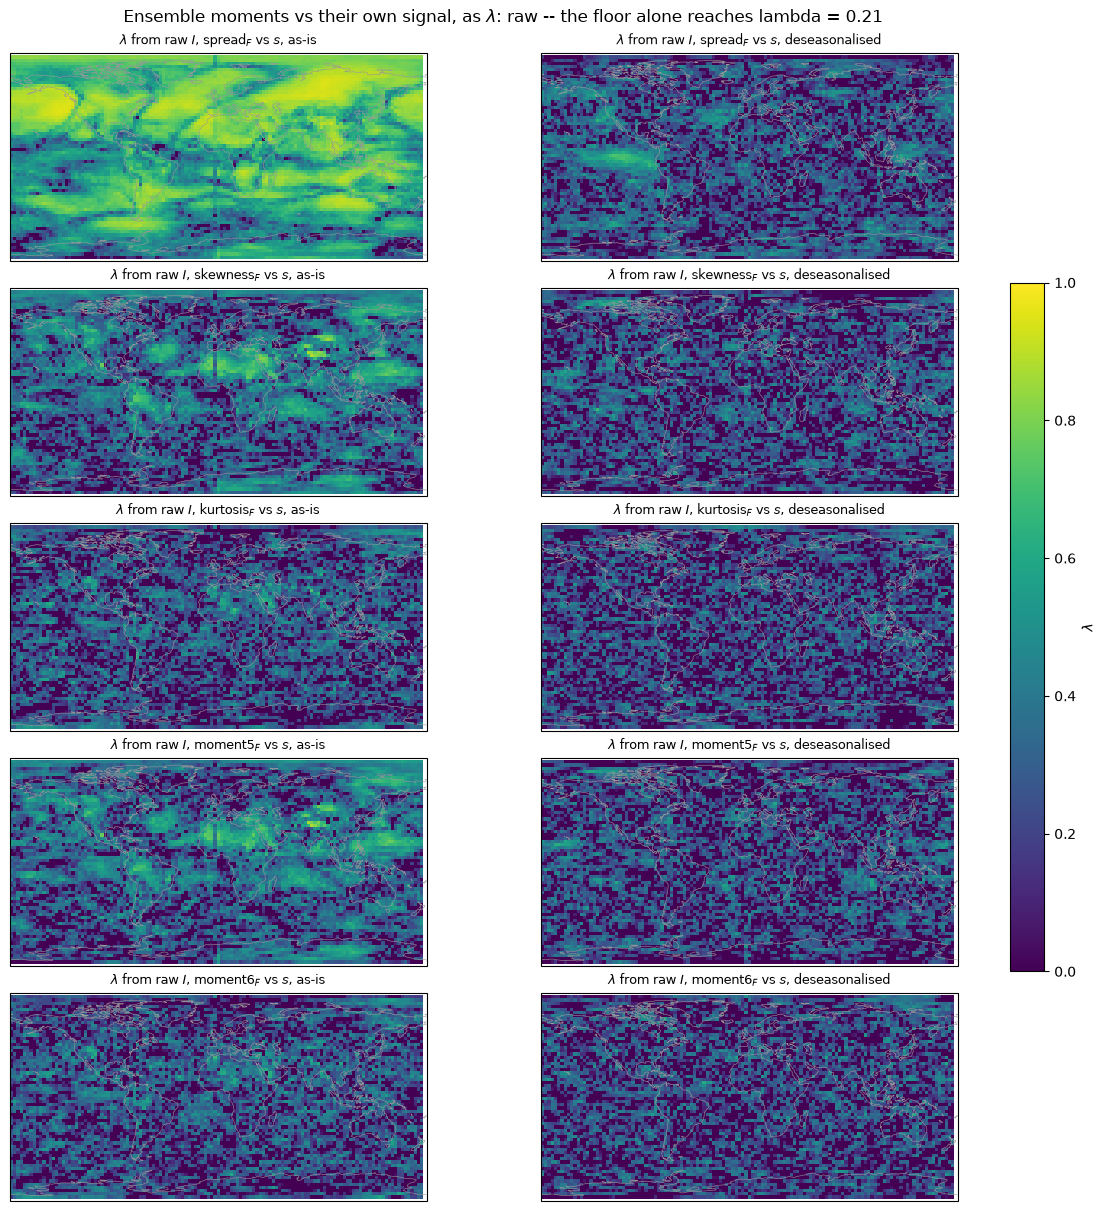

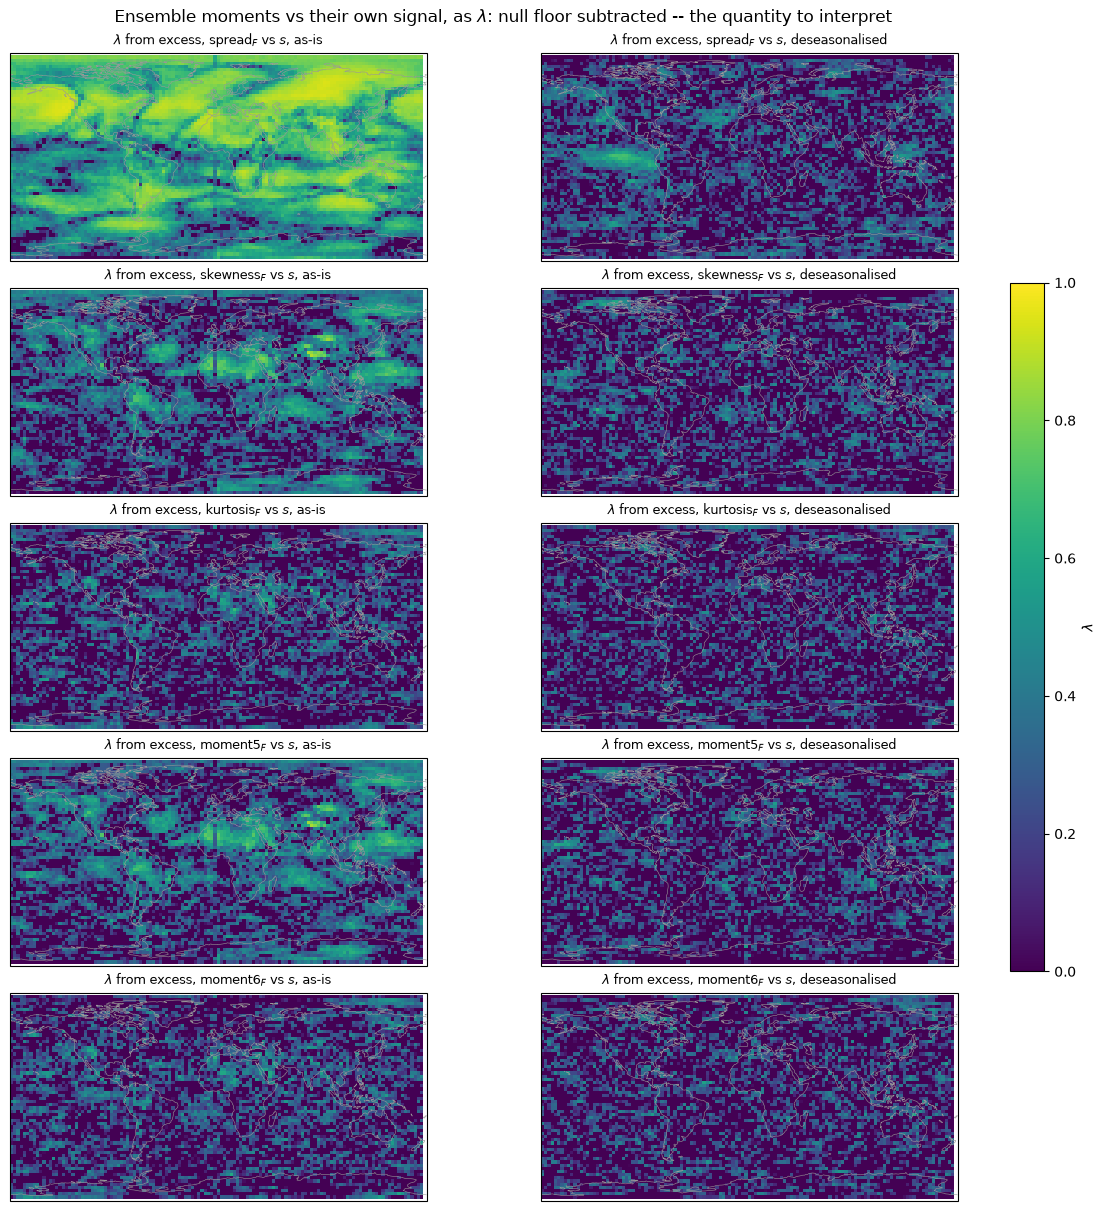

moment     version          lam(raw)  lam(exc)   %lam=0 mean null
spread     as-is               0.630     0.603     3.5%    0.0313
spread     deseasonalised      0.225     0.160    42.3%    0.0322
skewness   as-is               0.315     0.256    27.0%    0.0315
skewness   deseasonalised      0.195     0.133    48.8%    0.0316
kurtosis   as-is               0.220     0.156    43.2%    0.0319
kurtosis   deseasonalised      0.183     0.121    51.7%    0.0316
moment5    as-is               0.303     0.244    28.9%    0.0316
moment5    deseasonalised      0.189     0.128    50.4%    0.0316
moment6    as-is               0.217     0.152    44.6%    0.0317
moment6    deseasonalised      0.180     0.120    52.0%    0.0316

%lam=0 is where the clamp is active, i.e. excess < 0. Around 50% means the
panel is indistinguishable from no dependence; a small figure means real signal.


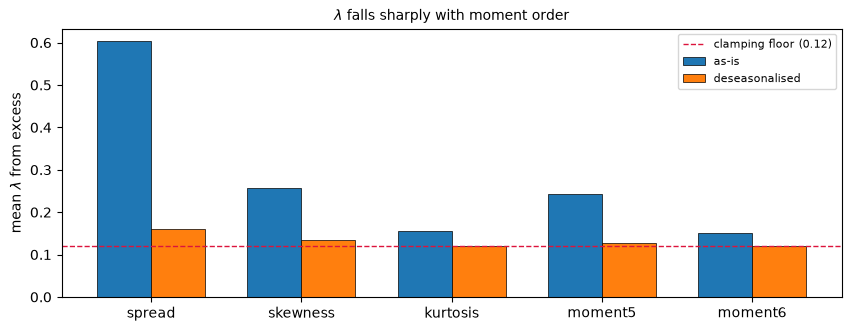

In [5]:
# The cache carries three fields per (moment, version). Naming them here because
# "ex" was doing far too much work for two letters:
#
#   raw_I  -- the KSG estimate of I(moment ; s) as it comes out
#   null_I -- the permutation-null floor: the same estimator on time-shuffled data,
#             where the true MI is zero by construction, so whatever it returns is bias
#   excess -- raw_I - null_I, the bias-corrected estimate. It is *signed*: KSG has no
#             non-negativity constraint, and excess differences two noisy estimates, so
#             with no real dependence it falls below zero about half the time.
def fields(nm, tag):
    key = "%s|%s" % (nm, tag)
    return EX[key + "|I"], EX[key + "|null"], EX[key]


def lam_clamped(I):
    """lambda = sqrt(1 - 2^(-2I)), with the argument of the sqrt clamped at 0.

    For I < 0 the argument 1 - 2^(-2I) is negative, and clamping it sends those cells
    to lambda = 0. That is algebraically the same as clamping I at 0 first, which is
    what R.lam does -- the two agree to 0.0e+00, verified below.
    """
    return np.sqrt(np.maximum(0.0, 1.0 - 2.0 ** (-2.0 * I)))


_t = np.linspace(-0.3, 1.0, 9)
print("clamping the sqrt argument vs clamping I (R.lam): max|diff| = %.1e"
      % np.max(np.abs(lam_clamped(_t) - R.lam(_t))))
print("lambda at the mean null floor I=0.032 : %.3f\n" % lam_clamped(0.032))

NORM = Normalize(0, 1)      # lambda is correlation-like and bounded by 1

for label, idx, blurb in (
        ("$\\lambda$ from raw $I$", 0, "raw -- the floor alone reaches lambda = 0.21"),
        ("$\\lambda$ from excess", 2, "null floor subtracted -- the quantity to interpret")):
    fig, axs = plt.subplots(len(MOMENTS), 2, figsize=(12, 2.4 * len(MOMENTS)), layout="constrained",
                            subplot_kw={"projection": PROJ})
    for i, (nm, _) in enumerate(MOMENTS):
        for j, tag in enumerate(VERSIONS):
            h = panel(axs[i, j], lam_clamped(fields(nm, tag)[idx]), "viridis", NORM,
                      "%s, $\\mathrm{%s}_F$ vs $s$, %s" % (label, nm, tag))
    fig.colorbar(h, ax=axs, shrink=0.6, label="$\\lambda$")
    fig.suptitle("Ensemble moments vs their own signal, as $\\lambda$: %s" % blurb,
                 fontsize=12)
    plt.show()

print("%-10s %-15s %9s %9s %8s %9s"
      % ("moment", "version", "lam(raw)", "lam(exc)", "%lam=0", "mean null"))
for nm, _ in MOMENTS:
    for tag in VERSIONS:
        raw_I, null_I, excess = fields(nm, tag)
        lr, le = lam_clamped(raw_I), lam_clamped(excess)
        print("%-10s %-15s %9.3f %9.3f %7.1f%% %9.4f"
              % (nm, tag, np.nanmean(lr), np.nanmean(le),
                 100 * np.mean(le == 0), np.nanmean(null_I)))
print("\n%lam=0 is where the clamp is active, i.e. excess < 0. Around 50% means the")
print("panel is indistinguishable from no dependence; a small figure means real signal.")

FLOOR = np.nanmean(lam_clamped(fields("moment6", "deseasonalised")[2]))
fig, ax = plt.subplots(figsize=(8.4, 3.2), layout="constrained")
w, xs = 0.36, np.arange(len(MOMENTS))
for j, tag in enumerate(VERSIONS):
    ax.bar(xs + (j - 0.5) * w,
           [np.nanmean(lam_clamped(fields(nm, tag)[2])) for nm, _ in MOMENTS],
           w, label=tag, edgecolor="k", linewidth=0.5)
ax.axhline(FLOOR, ls="--", lw=1, color="crimson",
           label="clamping floor (%.2f)" % FLOOR)
ax.set_xticks(xs)
ax.set_xticklabels([nm for nm, _ in MOMENTS])
ax.set_ylabel("mean $\\lambda$ from excess")
ax.set_title("$\\lambda$ falls sharply with moment order", fontsize=10)
ax.legend(fontsize=8)
plt.show()

## The same ten panels as Pearson correlation

Mutual information is unsigned and, because the adapter rank-transforms both variables,
it responds to *any* monotone relationship as well as non-monotone ones. Pearson $r$ sees
only the linear part -- but it keeps the **sign**, which the MI throws away. Plotting both
therefore says more than either alone: agreement means the dependence is essentially
linear, and disagreement localises where it is not.

The colour scale is symmetric about zero and spans $\pm0.6$. Because $\lambda$ is the
Gaussian-equivalent correlation, the $\lambda$ panels above and these $r$ panels are the
same kind of quantity and can be compared directly -- bearing in mind that $\lambda$ is
unsigned and carries the clamping floor near 0.12.

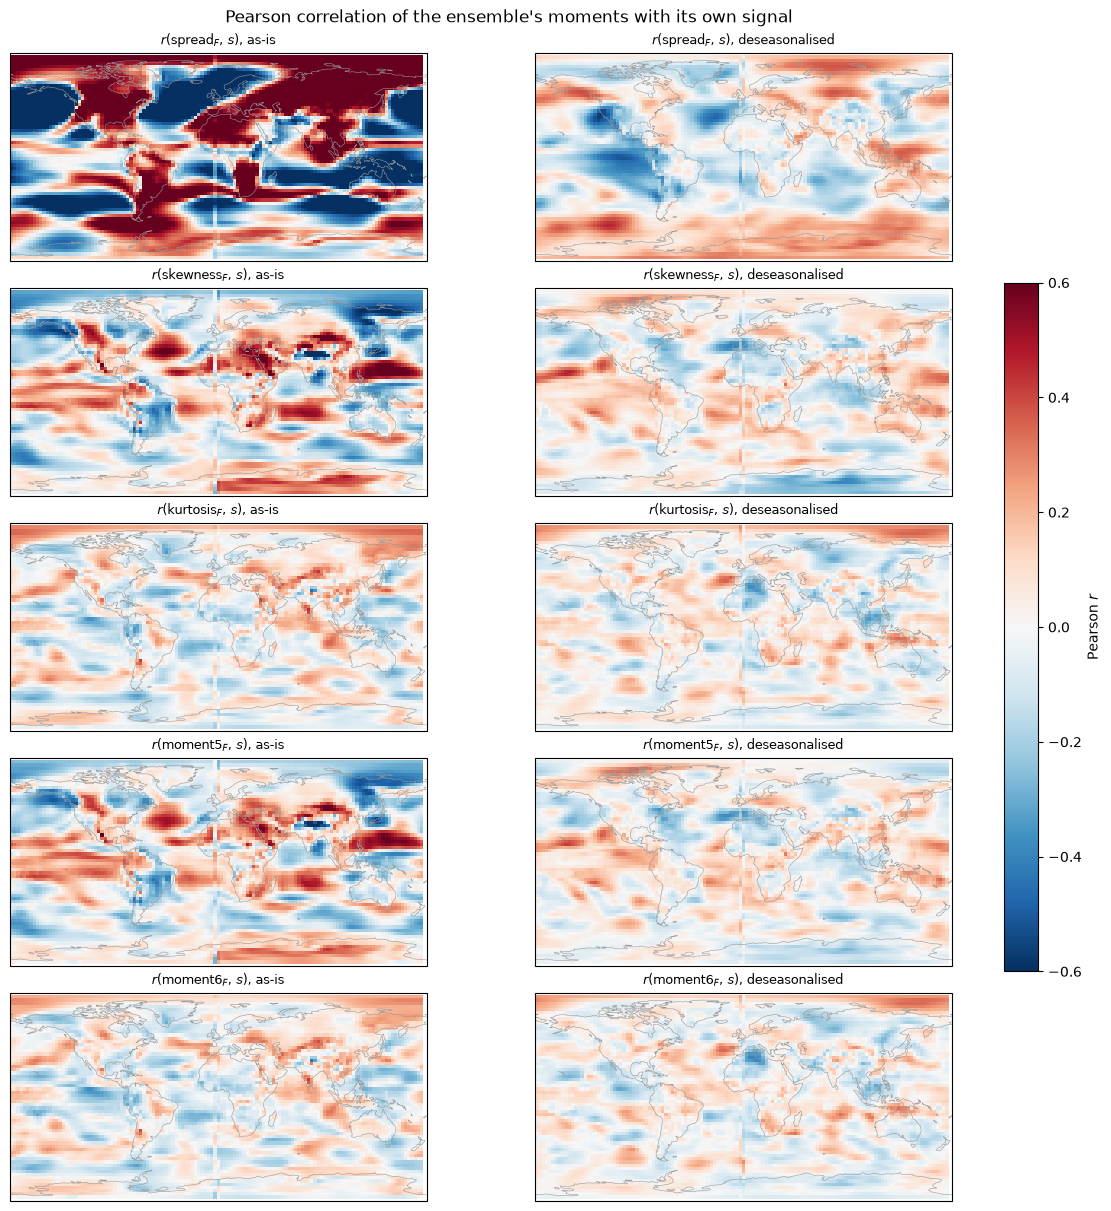

naive 95% threshold |r| > 0.181 at T=120 (ignores autocorrelation)

moment     version           mean r  mean|r| %|r|>crit  mean lam corr(|r|,lam)
spread     as-is             +0.066    0.438     78.1%     0.603     0.744
spread     deseasonalised    +0.019    0.146     30.9%     0.160     0.377
skewness   as-is             +0.009    0.186     44.6%     0.256     0.614
skewness   deseasonalised    +0.016    0.102     16.8%     0.133     0.221
kurtosis   as-is             +0.013    0.111     19.6%     0.156     0.292
kurtosis   deseasonalised    +0.012    0.085      8.6%     0.121     0.160
moment5    as-is             +0.011    0.165     41.5%     0.244     0.558
moment5    deseasonalised    +0.012    0.092     12.9%     0.128     0.213
moment6    as-is             +0.006    0.103     17.4%     0.152     0.255
moment6    deseasonalised    +0.008    0.081      8.3%     0.120     0.158

mean r for spread vs signal (as-is) by |lat| band -- where the sign lives:
   0-15 deg : -0.021
  15-3

In [6]:
def pearson(A, B):
    # correlation along the time axis at every grid cell, fully vectorised
    a = A - A.mean(axis=0, keepdims=True)
    b = B - B.mean(axis=0, keepdims=True)
    den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1), np.nan)


SGN_ds = deseason(SGN)
RR = {}
for nm, M in MOMENTS:
    RR["%s|as-is" % nm] = pearson(M, SGN)
    RR["%s|deseasonalised" % nm] = pearson(deseason(M), SGN_ds)

T = SGN.shape[0]
crit = 1.96 / np.sqrt(T - 3)      # naive 95% threshold; ignores autocorrelation

fig, axs = plt.subplots(len(MOMENTS), 2, figsize=(12, 2.4 * len(MOMENTS)), layout="constrained",
                        subplot_kw={"projection": PROJ})
rnorm = Normalize(-0.6, 0.6)
for i, (nm, _) in enumerate(MOMENTS):
    for j, tag in enumerate(VERSIONS):
        h = panel(axs[i, j], RR["%s|%s" % (nm, tag)], "RdBu_r", rnorm,
                  "$r(\\mathrm{%s}_F,\\,s)$, %s" % (nm, tag))
fig.colorbar(h, ax=axs, shrink=0.6, label="Pearson $r$")
fig.suptitle("Pearson correlation of the ensemble's moments with its own signal",
             fontsize=12)
plt.show()

print("naive 95%% threshold |r| > %.3f at T=%d (ignores autocorrelation)\n" % (crit, T))
print("%-10s %-15s %8s %8s %9s %9s %9s"
      % ("moment", "version", "mean r", "mean|r|", "%|r|>crit", "mean lam", "corr(|r|,lam)"))
for nm, _ in MOMENTS:
    for tag in VERSIONS:
        r = RR["%s|%s" % (nm, tag)]
        lam = R.lam(EX["%s|%s" % (nm, tag)])          # pointwise, excess clipped at 0
        m = np.isfinite(r) & np.isfinite(lam)
        print("%-10s %-15s %+8.3f %8.3f %8.1f%% %9.3f %9.3f"
              % (nm, tag, np.nanmean(r), np.nanmean(np.abs(r)),
                 100 * R.area_weighted_fraction(np.abs(r), lats, threshold=crit),
                 np.nanmean(lam), np.corrcoef(np.abs(r)[m], lam[m])[0, 1]))

print("\nmean r for spread vs signal (as-is) by |lat| band -- where the sign lives:")
r_sd = RR["spread|as-is"]
for a, b in [(0, 15), (15, 30), (30, 60), (60, 90)]:
    sel = (np.abs(lats) >= a) & (np.abs(lats) < b)
    print("  %2d-%2d deg : %+.3f" % (a, b, np.nanmean(r_sd[sel])))

### What the correlation adds

**The relationship changes sign regionally, and MI cannot see that.** For as-is spread the
mean $r$ is only $+0.066$ while the mean $|r|$ is $0.438$ -- large local correlations that
very nearly cancel globally. Broken down by latitude, $r$ is flat near zero through the
tropics and midlatitudes ($-0.021$, $-0.001$, $-0.017$) and clearly positive poleward of
$60^\circ$ ($+0.243$): at high latitudes a higher pressure signal really does come with a
wider ensemble. That structure is invisible in the $\lambda$ maps, which are non-negative by
construction. Every moment shows the same thing -- mean $r$ between $+0.006$ and $+0.019$
against mean $|r|$ several times larger -- so in every case the sign is regional and cancels.

**Otherwise the two measures agree, and agree less as the signal weakens.** The spatial
correlation between $|r|$ and $\lambda$ for the as-is fields is $0.744$ for spread, then
$0.614$, $0.292$, $0.558$, $0.255$ for $m_3$ to $m_6$; the deseasonalised versions run
$0.377$, $0.221$, $0.160$, $0.213$, $0.158$. Where there is signal both measures find it in
the same places; where there is none they disagree because both are describing noise.

**$\lambda$ sits consistently above $|r|$, and the gap is mostly the clamp.** For as-is
spread the gap is $+0.165$, but in the panels with essentially no signal it is still
$+0.014$ to $+0.039$ -- and those panels have no dependence to detect, so that residual is
the clamping bias rather than nonlinearity. Only the spread's much larger gap reflects
genuine dependence a linear coefficient misses, helped by the rank transform making the MI
sensitive to any monotone relationship rather than only a straight line.

**Practical reading:** report both. Pearson for sign and a familiar effect size, $\lambda$
for whether any dependence exists at all.

**Two artefacts in the figure, not findings.** The as-is spread panel saturates against the
$\pm0.6$ scale over large areas -- the scale is held there deliberately so the weak panels
stay legible, but read that panel as "strong" rather than off its colour value. And a pale
vertical line runs down the prime meridian in most panels: longitude columns 0 and 127 are
20.7% and 42.9% NaN because the wrap-around is not handled before `interp_like`, so those
two columns are the least trustworthy on every map in this notebook.

### Are $m_5$ and $m_6$ saying anything new?

The Pearson figure makes the odd/even split look suspiciously strong: the $m_3$ and $m_5$
rows are near-copies of each other, and so are $m_4$ and $m_6$. Worth checking directly,
because "weak" and "redundant" are different verdicts and only one of them means the extra
moments were never worth computing.

In [7]:
pairs = [("skewness", M3), ("kurtosis", M4), ("moment5", M5), ("moment6", M6)]

print("correlation between the moment time series, averaged over grid cells")
for i, (na, A) in enumerate(pairs):
    for nb_, B in pairs[i + 1:]:
        print("  %-9s vs %-9s   mean r %+.3f" % (na, nb_, np.nanmean(pearson(A, B))))

print("\nspatial correlation between the r(moment, s) maps themselves")
for i, (na, _) in enumerate(pairs):
    for nb_, _ in pairs[i + 1:]:
        a, b = RR["%s|as-is" % na], RR["%s|as-is" % nb_]
        m = np.isfinite(a) & np.isfinite(b)
        print("  r(%-9s,s) vs r(%-9s,s)   %+.3f" % (na, nb_, np.corrcoef(a[m], b[m])[0, 1]))

correlation between the moment time series, averaged over grid cells
  skewness  vs kurtosis    mean r +0.025
  skewness  vs moment5     mean r +0.927
  skewness  vs moment6     mean r +0.023
  kurtosis  vs moment5     mean r +0.028
  kurtosis  vs moment6     mean r +0.961
  moment5   vs moment6     mean r +0.026

spatial correlation between the r(moment, s) maps themselves
  r(skewness ,s) vs r(kurtosis ,s)   -0.235
  r(skewness ,s) vs r(moment5  ,s)   +0.983
  r(skewness ,s) vs r(moment6  ,s)   -0.223
  r(kurtosis ,s) vs r(moment5  ,s)   -0.241
  r(kurtosis ,s) vs r(moment6  ,s)   +0.974
  r(moment5  ,s) vs r(moment6  ,s)   -0.233


## Findings

$\lambda$ from the null-corrected MI, and the Pearson $|r|$, for all five moments:

| moment | as-is $\lambda$ | area $>0$ | deseason. $\lambda$ | area $>0$ | as-is $\|r\|$ | seasonal var. |
|---|---|---|---|---|---|---|
| spread | **0.603** | 97.5% | **0.160** | 59.0% | 0.438 | 0.665 |
| $m_3$ skewness | 0.256 | 74.3% | 0.133 | 53.2% | 0.186 | 0.227 |
| $m_4$ kurtosis | 0.156 | 58.6% | 0.121 | 49.0% | 0.111 | 0.128 |
| $m_5$ | 0.244 | 73.1% | 0.128 | 51.8% | 0.165 | 0.185 |
| $m_6$ | 0.152 | 57.9% | 0.120 | 48.4% | 0.103 | 0.119 |

**Nothing survives the seasonal control except the spread, and barely.** Deseasonalised
$\lambda$ is 0.133, 0.121, 0.128, 0.120 for $m_3$ through $m_6$ -- all at or below the
**0.12 clamping floor** established earlier, with the positive-excess area between 48.4% and
53.2% against the 50% expected by chance. $m_6$'s mean excess is actually $-0.0006$ bits.
These are null results, stated as such. Only the spread clears its floor at all, at
$\lambda = 0.160$ over 59.0% of the area, and even that is marginal.

**The pattern across orders is odd/even, not a decline.** This was the surprise. In the
as-is fields the odd moments carry roughly $\lambda = 0.25$ ($m_3$ 0.256, $m_5$ 0.244) and
the even ones roughly $0.15$ ($m_4$ 0.156, $m_6$ 0.152) -- so the 5th moment beats the 4th,
and order alone does not predict information content. Odd moments measure *asymmetry* and
even moments measure *tailedness*, and asymmetry is the more informative of the two about
$s$. The same split appears in the seasonal variance fractions (0.227, 0.128, 0.185, 0.119)
and in the $|r|$-to-$\lambda$ agreement (0.614, 0.292, 0.558, 0.255).

**And $m_5$, $m_6$ are not merely weak -- they are redundant.** The $m_3$ and $m_5$ time
series correlate at $+0.927$, and $m_4$ with $m_6$ at $+0.961$, while every odd-versus-even
pair sits near $+0.03$. The derived $r(\cdot\,;s)$ maps are even closer copies: $+0.983$
for $m_3$ against $m_5$ and $+0.974$ for $m_4$ against $m_6$, with cross-parity pairs at
about $-0.23$. At $N=49$ a fifth or sixth moment is dominated by the same handful of
outlying members that already set the third and fourth, so it re-measures them rather than
adding a new view. That is why the odd/even split is so clean: there are really only two
independent shape statistics here, asymmetry and tailedness, and going to higher order
recovers the same two.

**But that split vanishes after deseasonalising**, which locates it. It is a property of the
annual cycle -- the pressure distribution skews differently from season to season -- rather
than state-dependent predictability. Reading the as-is column alone would have produced a
confident and wrong story about asymmetry mattering.

**Why so little is detectable, quantified.** Sampling noise measured by Monte Carlo at
$N=49$ is 0.330, 0.603, 3.159 and 8.158 for $m_3$ to $m_6$ -- growing **25-fold** across
those four orders -- against observed variability of 0.427, 0.783, 4.447 and 12.790. Noise
is 64% to 77% of the total spread of every one of these moments, so most of what varies is
not signal. Whatever remains then has to clear a permutation floor near 0.032 bits, which
already exceeds the entire deseasonalised excess of every moment above the second.

**Conclusion, unchanged by adding two more orders.** Once seasonality is controlled, the
ensemble's distributional shape is essentially independent of its own signal, exactly as
homoscedastic signal-plus-noise predicts. The spread retains a weak, marginally detectable
dependence; $m_3$ through $m_6$ retain nothing. Carry $(\bar F, \sigma_F)$ as a predictor
and stop there -- the third through sixth moments would cost four dimensions and contribute
no information.

The caveat that bounds all of this: $N=49$ and $T=120$. A larger ensemble would make the
higher moments measurable and a longer record would lower the detection floor. Nothing here
says the atmosphere has no state-dependent skewness -- only that this dataset cannot see it,
and the Monte-Carlo noise figures say roughly how much larger an ensemble would need to be.